# CLUSTER NUMBERS AS QUASISYMMETRIES

This notebook is a copy of workflow_example.ipynb, which I am adapting to cluster spins as quasisymmetries. The new source code is in dam/cluster_number.py, and tested in dam/test_cluster_number.py. I will work directly with H2O.

In [1]:
# import new functions located in cluster_number.py

import cluster_number, utils

In [2]:
# ============================================================================
# SECTION 1: HAMILTONIAN GENERATION
# ============================================================================
"""
Create molecular Hamiltonian.
This produces a .chk file containing one- and two-electron integrals (AO basis, but easy to transform).
"""

import sys
import pyscf
import numpy as np
from scipy.special import binom
sys.path.append('../')
from chemistry import get_geometry_and_description


# --- Step 1.1: Define molecular geometry ---
molecule = "h2o"
bond_length = 1. 
hoh_angle_deg=104.5
geometry, description = get_geometry_and_description(molecule, bond_length, hoh_angle_deg=hoh_angle_deg)
print(f"Geometry: {geometry}")
print(f"Description: {description}")

# --- Step 1.2: Build PySCF molecule and run Hartree-Fock ---
mol = pyscf.M()
mol.build(atom=geometry, basis="sto-3g")
mf = pyscf.scf.RHF(mol)
mf.chkfile = f"hamiltonians/{description}.chk"  # Will save to this file
mf.kernel()  # Run SCF calculation

# !! From now on and until we start doing orbital rotations, the "orbitals" are always the HF MOs we just obtained.

print(f"HF Energy: {mf.e_tot:.8f} Hartree")
print(f"Number of orbitals: {mol.nao}")
print(f"Number of alpha and beta electrons: {mol.nelec}")
print(f"Space dimension (fixed N_alpha, N_beta): {int(binom(mol.nao, mol.nelec[0]) * binom(mol.nao, mol.nelec[1]))}")
# print(f"Coeffs of MOs:\n{mf.mo_coeff}")

Geometry: [('O', (0.0, 0.0, 0.0)), ('H', (np.float64(0.7906895737438433), np.float64(0.6122172800344493), 0.0)), ('H', (np.float64(-0.7906895737438433), np.float64(0.6122172800344493), 0.0))]
Description: H2O_OH1.0000_104.5000
converged SCF energy = -74.9646625391309
HF Energy: -74.96466254 Hartree
Number of orbitals: 7
Number of alpha and beta electrons: (5, 5)
Space dimension (fixed N_alpha, N_beta): 441



FCI Energy: -75.01985480 Hartree

Number of single-orbital num operators (should be as many as orbitals): 7

Number of two-orbital num operators, should be (# norb^2 - # norb)/2: 21

Variable type of each operator: <class 'scipy.sparse.linalg._interface._CustomLinearOperator'>

Variable type of h: <class 'scipy.sparse.linalg._interface._CustomLinearOperator'>


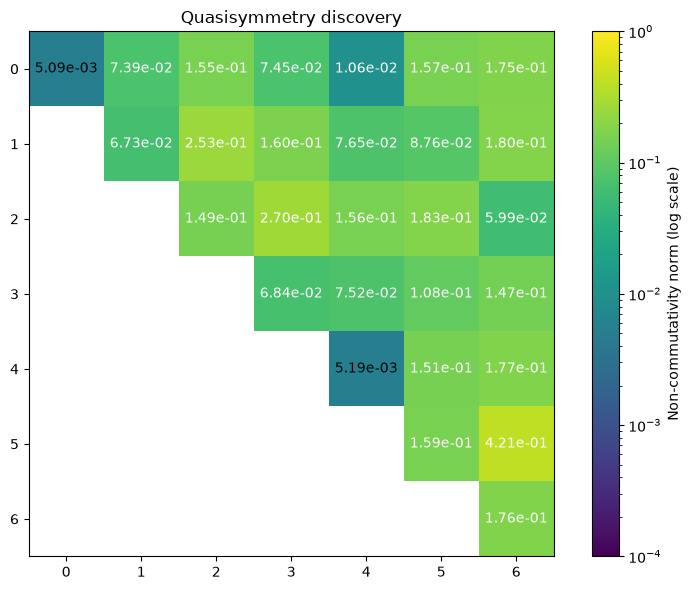

In [3]:
# ============================================================================
# SECTION 2: QUASISYMMETRY DISCOVERY
# ============================================================================
"""
Use show_symmetries.py logic to visualize which single-orbital and two-orbital squared spins have a small commutator "on" for a reference state.

 1. 
Computes non-commutativity scores for:
• single-orbital squared spin i.e. seniority: NC(i,i) = ||[H, S_i^2]|Ψ⟩||² (diagonal)
• two-orbital squared spin: NC(i,j) = ||[H, S_ij^2]|Ψ⟩||² (off-diagonal)
 2. 
Visualizes results as a heatmap (log scale) where:
• Dark spots = small commutator = good quasisymmetry candidate
• Bright spots = poor candidates
"""

import ffsim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from optimize_orbitals import parities, get_fci

# --- Step 2.1: Load molecular data using objects mol and mf from previous cell ---
moldata = pyscf.lib.chkfile.load_mol(mf.chkfile)
mf_update = pyscf.scf.RHF(mol) # why again?
mf_update.update_from_chk(mf.chkfile)
moldata_ffsim = ffsim.MolecularData.from_scf(mf_update)

# Prepare the molecular integrals in FCI-compatible format needed by PySCF's FCI solver.
dumpdata = { # (dump means save/write out)
    "NORB": mol.nao,
    "NELEC": mol.nelec,
    "H1": mf.mo_coeff.T @ (mol.intor("int1e_kin") + mol.intor("int1e_nuc")) @ mf.mo_coeff,
    "H2": pyscf.ao2mo.full(mol, mf.mo_coeff),
    "ECORE": mol.energy_nuc()
}

# --- Step 2.2: Compute FCI reference state ---
e_fci, fci_state = get_fci(dumpdata) # optimize_orbitals.get_fci calls pyscf.fci.direct_spin1.FCI
print(f"\nFCI Energy: {e_fci:.8f} Hartree")
# print(f"FCI state: {fci_state}")

# --- Step 2.3: Define spin operators ---
one_orb_num_operators = cluster_number.build_one_orb_num_operators(moldata_ffsim.norb, moldata_ffsim.nelec)
print(f"\nNumber of single-orbital num operators (should be as many as orbitals): {len(one_orb_num_operators)}")
two_orb_num_operators = cluster_number.build_two_orb_num_operators(moldata_ffsim.norb, moldata_ffsim.nelec)
print(f"\nNumber of two-orbital num operators, should be (# norb^2 - # norb)/2: {len(two_orb_num_operators)}")
example_op = one_orb_num_operators[0]
print(f"\nVariable type of each operator: {type(example_op)}")
# SciPy's matrix-free linear operator: a lightweight wrapper that knows how to apply the (sparse) operator to a vector. Can also use @, eigsh, ... with it. Good to keep in mind!

# --- Step 2.4: Compute commutator norms ---
norb = moldata_ffsim.norb
h = ffsim.linear_operator(moldata_ffsim.hamiltonian, norb, moldata_ffsim.nelec) # the hamiltonian refers to HF MO orbital basis; this is the line of this cell where we are choosing the reference orbital basis
print(f"\nVariable type of h: {type(h)}") # same "wrapper" type

# compute noncommutation scores with our data
nc_scores = utils.get_heatmap_data(h, fci_state, norb, one_orb_num_operators, two_orb_num_operators, upscale_factor=1)

# --- Step 2.5: Visualize the non-commutativity heatmap ---
utils.show_heatmap(nc_scores, vmin = 1e-4, vmax = 1e0)

"""
NOTES ON SECTION 2:
- Dark spots in the heatmap indicate good quasisymmetry candidates
"""

print()


Cluster matrix (3 quasisymmetries, 7 orbitals):
[[0 0 1 1 0 0 0]
 [0 0 0 0 1 0 1]
 [0 1 0 0 0 1 0]]
Number of quasisymmetry operators: 3

Initial cost (identity rotation): 5.344630e-01

Running orbital optimization...


/var/folders/r2/2ny_rjqj5w93mz1ll0gd2vbr0000gp/T/ipykernel_9660/4060554819.py:54: OptimizeWarning: Unknown solver options: disp
  result = scipy.optimize.minimize(


Optimized cost: 4.034436e-01
Cost change: -24.51%

For reference, % cost change for some random unitaries: 12151, 20101, 14492%

New heatmap after orbital rotations (relevant if clusters have one or two orbitals):


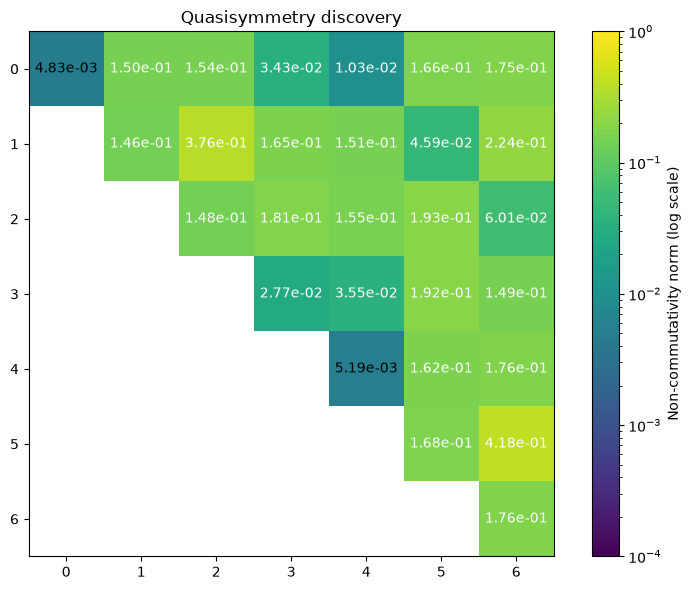

In [4]:
# ============================================================================
# SECTION 3: ORBITAL OPTIMIZATION
# ============================================================================
"""
Now we:
1. Select one or more quasisymmetries (based on heatmap), i.e., one- or two-orbital squared spins
2. Optimize the orbital rotation to minimize the commutator cost

"""

from optimize_orbitals import commutator_cost, x_to_rotation
import scipy.optimize
from math import comb

# --- Step 3.1: Define the cluster matrix; refers to spatial orbitals ---

# choice 1
cluster_matrix = np.array([
    [1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 1, 0]
])

# choice 2: all orbitals, taken singularly
cluster_matrix = np.eye(7)

# choice 3: some pairs of orbitals whose corresponding heat map tile is darkest
cluster_matrix = np.array([
    [0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 1, 0]
])

print(f"\nCluster matrix ({cluster_matrix.shape[0]} quasisymmetries, {cluster_matrix.shape[1]} orbitals):")
print(cluster_matrix)

# --- Step 3.2: Convert cluster matrix to quasisymmetry operators ---
symmetries = cluster_number.cluster_matrix_to_cluster_number_quasisymmetries(
    cluster_matrix, moldata_ffsim.norb, moldata_ffsim.nelec)
print(f"Number of quasisymmetry operators: {len(symmetries)}")

# --- Step 3.3: Define the cost function ---
# Cost = sum over symmetries S_k of ||[H(U), S_k]|Ψ(U)⟩||²
# We optimize over orbital rotation parameters x (anti-symmetric matrix)
f = cluster_number.commutator_cost_v2(moldata_ffsim, symmetries, fci_state) # commutator_cost builds the cost function f: x upper triangle of antisym matrix |-> \sum_k ||[H(rotated with exp(x)), S_k]|Ψ(rotated with exp(x)⟩||²

# --- Step 3.4: Initial guess (identity rotation) ---
x0 = np.zeros(comb(norb, 2))
initial_cost = f(x0)
print(f"\nInitial cost (identity rotation): {initial_cost:.6e}")

# --- Step 3.5: Optimize using L-BFGS-B ---
print("\nRunning orbital optimization...")
result = scipy.optimize.minimize(
    f, x0,
    method='L-BFGS-B',
    options={'maxiter': 30, 'disp': True}
)
optimized_cost = result.fun
print(f"Optimized cost: {optimized_cost:.6e}")
print(f"Cost change: {(- initial_cost + optimized_cost)/initial_cost * 100:.2f}%")

# --- Step 3.6: Extract optimized orbital rotation ---
x_opt = result.x
U_opt = x_to_rotation(x_opt, norb)
# print(f"\nOptimized rotation matrix U:")
# print(U_opt)

# --- Step 3.7: Compare with randomly rotated orbitals ---
num_random_Us = 3
xs_random = [10 * np.random.rand(comb(norb, 2)) for _ in range(num_random_Us)]
random_costs = [f(x_random) for x_random in xs_random]
random_costs_perc = [int((- initial_cost + random_cost)/initial_cost * 100) for random_cost in random_costs]
print(f"\nFor reference, % cost change for some random unitaries: {", ".join(map(str, random_costs_perc))}%")

# --- Step 3.8: New heatmap with optimally rotated orbitals ---

rotated_h = moldata_ffsim.hamiltonian.rotated(U_opt)
rotated_h_linop = ffsim.linear_operator(rotated_h, norb, moldata_ffsim.nelec)
rotated_fci_state = ffsim.apply_orbital_rotation(
    fci_state, U_opt, norb, moldata_ffsim.nelec)

rotated_nc_scores = utils.get_heatmap_data(rotated_h_linop, rotated_fci_state, norb, one_orb_num_operators, two_orb_num_operators, upscale_factor=1)

print("\nNew heatmap after orbital rotations (relevant if clusters have one or two orbitals):")

utils.show_heatmap(rotated_nc_scores, vmin = 1e-4, vmax = 1e0)

"""
NOTES ON SECTION 3:
- The optimization finds U that minimizes the commutator norm
- The orbital rotation U transforms the molecular orbitals to a new basis
where the quasisymmetries commute better with the Hamiltonian.
"""



print("\n")


In [5]:
# ============================================================================
# SECTION 4: METRICS EVALUATION
# ============================================================================
"""
Now we evaluate the quality of the subspace decomposition by:
1. Identifying symmetry sectors
2. Building subspace Hamiltonians
3. Computing K: minimal number of states needed for chemical accuracy

Chemical accuracy = 1.6 mHa = 0.0016 Hartree
"""

from metrics import symmetry_sectors, subspace_matrix, orthogonalize_degenerate
from chemistry import CHEMICAL_PRECISION
from math import comb

# --- Step 4.1: Apply optimized rotation to Hamiltonian and state (if not done yet) ---
rotated_h = moldata_ffsim.hamiltonian.rotated(U_opt)
rotated_h_linop = ffsim.linear_operator(rotated_h, norb, moldata_ffsim.nelec)
rotated_fci_state = ffsim.apply_orbital_rotation(
    fci_state, U_opt, norb, moldata_ffsim.nelec)

# --- Step 4.2: Identify symmetry sectors by partitioning the computational/fock basis --- 
# Each configuration/bitstring/basis SD gets assigned to a sector based on
# the eigenvalues of our quasisymmetries
sectors = cluster_number.cluster_number_symmetry_sectors(cluster_matrix, norb, moldata_ffsim.nelec)
print(f"\nNumber of alpha/beta elecs: {moldata_ffsim.nelec}")
print(f"Corresponding total number of configurations = total dimension: {comb(norb, moldata_ffsim.nelec[0]) * comb(norb, moldata_ffsim.nelec[1])}")
print(f"Number of symmetry sectors identified: {len(sectors)}")
for sector_label, sector_indices in sectors.items():
    print(f"  Sector {sector_label}: {len(sector_indices)} configurations")
print(f"Sectors full dict: {sectors} \n")

# --- Step 4.3: Build subspace Hamiltonians ---
sector_hamiltonians = {}
for sector_label, sector_indices in sectors.items():
    sector_hamiltonians[sector_label] = subspace_matrix( # should still be able to reuse Aleksey's subspace_matrix here!
        rotated_h_linop, sector_indices)                # (although can substitute with std submatrix extraction functions)
    print(f"  Sector {sector_label}: Hamiltonian shape {sector_hamiltonians[sector_label].shape}")

print(" ")

# --- Step 4.4: Diagonalize each sector --- # I will keep this part, although not what I am most interested about
sector_energies = {}
sector_states = {}
for label, h_sub in sector_hamiltonians.items():
    # Get all eigenvalues (full diagonalization for small systems)
    w, v = np.linalg.eigh(h_sub)
    v_orth = orthogonalize_degenerate(w, v)
    sector_energies[label] = w
    sector_states[label] = v_orth
    print(f"  Sector {label}: {len(w)} states, ground energy = {w[0]:.8f}")

# --- Step 4.5: Find the global ground state in decoupled sectors ---
# Each sector has its own ground state. The true ground state is the minimum.
sector_ground_energies = {label: energies[0] for label, energies in sector_energies.items()}
global_min_sector = min(sector_ground_energies, key=sector_ground_energies.get)
e_decoupled = sector_ground_energies[global_min_sector]
print(f"\nDecoupled ground state energy: {e_decoupled:.8f}")
print(f"FCI energy: {e_fci:.8f}")
print(f"Energy error: {e_decoupled - e_fci:.8f} Hartree = {(e_decoupled - e_fci)*27.2114:.4f} eV")

# --- Step 4.6: Construct full-space basis from sector states ---
# Collect all sector states into a single matrix
full_space_vectors = []
sector_labels_list = []
for label, indices in sectors.items():
    # Get the states for this sector
    v_sector = sector_states[label]
    n_states = v_sector.shape[1]

    # Create full-space vectors (zeros everywhere except in this sector)
    vectors_in_sector = np.zeros((rotated_h_linop.shape[0], n_states),
                                dtype='complex')
    vectors_in_sector[indices, :] = v_sector
    full_space_vectors.append(vectors_in_sector)

    # Track which sector each state belongs to
    for i in range(n_states):
        sector_labels_list.append((label, i))

print(f"\n Full space vectors (each column is an eigenvector of the QSs and of the hamiltonian restricted to the corresponding QS sector): \n{full_space_vectors}") # basis ordering for two orbitals and Nalpha = Nbeta = 1: |alpha beta, 0>, |alpha, beta>, |beta, alpha>, |0, alpha beta>
print(f"\n Sector labels list (QS label of the vectors just printed): \n{sector_labels_list}")

# Concatenate all sector states
full_space_vectors_cat = np.concatenate(full_space_vectors, axis=1) # block diag unitary up to reordering only columns or only rows, i.e., full change of basis matrix from initial SDs to basis of sim. eigenvectors of the QSs and of the hamiltonian restricted
print(f"\n full_space_vectors_cat: \n {full_space_vectors_cat}")
print(f"\nTotal number of sector states: {full_space_vectors_cat.shape[1]}")
print(f"Full Hilbert space dimension: {rotated_h_linop.shape[0]}")

# --- Step 4.7: Project FCI state onto sector states ---
# This tells us how much of the FCI state lives in each sector
coefficients = full_space_vectors_cat.T.conj() @ rotated_fci_state
print(f"\nFCI state coefficients in sector basis:")
for i, (label, state_idx) in enumerate(sector_labels_list):
    print(f"  Sector {label}, state {state_idx}: |c|² = {np.abs(coefficients[i])**2:.9f}")

# --- Step 4.8: Calculate K directly ---
"""
K is the minimal number of sector states *distributed across sectors*
needed to recover the FCI ground state energy to chemical accuracy.

We sort sector states by their contribution to the FCI state and
accumulate until the projected energy is within 0.0016 Ha of FCI.
"""

# Sort coefficients by magnitude (most important first)
sorted_indices = np.argsort(np.abs(coefficients))[::-1]

# Function to compute projected energy using top K states; see metrics.f; rewritten here for clarity
def projected_energy(K):
    """Compute energy using only the K most important sector states"""
    # Create compressed coefficient vector
    compressed_coeffs = np.zeros_like(coefficients, dtype='complex')
    compressed_coeffs[sorted_indices[:K]] = coefficients[sorted_indices[:K]]

    # Normalize
    compressed_coeffs /= np.linalg.norm(compressed_coeffs)

    # Projected state in full space
    projected_state = full_space_vectors_cat @ compressed_coeffs
    projected_state /= np.linalg.norm(projected_state) # redundant

    # Compute energy
    e_proj = projected_state.T.conj() @ rotated_h_linop @ projected_state
    return e_proj.real



# Find minimal K
K_values = []
energies = []
for K in range(1, len(coefficients) + 1):
    e_K = projected_energy(K)
    energies.append(e_K)
    K_values.append(K)
    error = e_K - e_fci
    print(f"  K={K:2d}: E={e_K:.8f}, Error={error:.8f} Ha = {error*27.2114:.4f} eV")
    if error < CHEMICAL_PRECISION:
        print(f"  --> Chemical accuracy achieved at K={K}!")
        break

# Plot energy error vs K
plt.figure(figsize=(8, 5))
plt.plot(K_values, [e - e_fci for e in energies], 'o-')
plt.axhline(CHEMICAL_PRECISION, color='r', linestyle='--', label='Chemical accuracy')
plt.axhline(0, color='k', linestyle=':', alpha=0.3)
plt.xlabel('K (number of sector states)')
plt.ylabel('Energy error (Ha)')
plt.title(f'K Convergence for H2 (bond={bond_length}Å)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

"""
NOTES ON SECTION 4:
- K=1 means the ground state of a single sector recovers chemical accuracy
- For well-chosen quasisymmetries, K is much smaller than the full Hilbert space
- For H2 at 2.0Å with STO-3G: full space has 4 states, we often get K=1 or K=2
- The energy error plot shows how quickly we converge to FCI

PHYSICAL INTERPRETATION:
When K is small, it means the quasisymmetry successfully decomposes the
Hilbert space such that the ground state is well-approximated by a small
number of states from a few sectors.
"""

print("\n")

AttributeError: module 'cluster_number' has no attribute 'cluster_number_symmetry_sectors'

In [ ]:
################################################################################################
# #TODO Write a part about not total number K of fixed-QS eigenstates, but just of total number of needed QS sectors
# i.e. min_num_sectors = lowest n s.t. the projection of psi onto the n highest-weight sectors is within chemical accuracy of exact E
# (not much to learn for H2O but relevant for bigger molecules)
################################################################################################

In [ ]:
################################################################################################
# #TODO scatterplots K against commutator-based NC score; min_num_sectors against commutator-based NC score.
# each data point corresponding to a randomly (how?) sampled cluster_matrix and orb. rot. U; with option to fix either cluster_matrix, or U
################################################################################################

In [ ]:

# ============================================================================
# SECTION 5: COMPLETE WORKFLOW SUMMARY
# ============================================================================


print("\n" + "="*70)
print("WORKFLOW SUMMARY")
print("="*70)
print(f"Basis: STO-3G ({norb} spatial orbitals)")
print(f"Electrons: {mol.nelec}")
print()
print(f"1. Hamiltonian Generation:")
print(f"   - HF Energy: {mf.e_tot:.8f} Ha")
print(f"   - FCI Energy: {e_fci:.8f} Ha")
print()
print(f"2. Quasisymmetry Discovery:")
print(f"   - Tested {norb} single-orbital numbers and {comb(norb,2)} orbital-pair-numbers")
print()
print(f"3. Orbital Optimization:")
print(f"   - Initial cost: {initial_cost:.6e}")
print(f"   - Optimized cost: {optimized_cost:.6e}")
print(f"   - Cost reduction: {(initial_cost - optimized_cost)/initial_cost * 100:.2f}%")
print()
print(f"4. Metrics Evaluation:")
print(f"   - Number of sectors: {len(sectors)}")
print(f"   - Decoupled ground energy: {e_decoupled:.8f} Ha")
print(f"   - Energy error (decoupled): {e_decoupled - e_fci:.8f} Ha")
print(f"   - K value: {K} sector states needed for chemical accuracy")
print(f"   - Full space dimension: {rotated_h_linop.shape[0]}")
#TODO print from last cell

In [ ]:

# ============================================================================
# SECTION 6: EXPLANATION OF KEY FUNCTIONS
# ============================================================================
"""
This section provides deeper explanation of the core functions used above.
"""

print("\n" + "="*70)
print("KEY FUNCTION EXPLANATIONS")
print("="*70)

print("""
1. build_one_orb_num_operators(norb, nelec) -> List[LinearOperator]
   build_two_orb_num_operators(norb, nelec) -> List[LinearOperator]
   - Creates one- or two- orbital number operators for all orbitals/pairs of orbitals
   - Returns as linear operators in the Fock space

2. cluster_matrix_to_quasisymmetries(cluster_matrix, norb, nelec) -> List[LinearOperator]
   - Converts binary matrix to quasisymmetry operators
   - Each row defines a quasisymmetry, 1s correspond to selected orbitals, 0s to orbitals left out
   - treats spatial orbitals (both spins together)

3. commutator_cost(moldata, symmetries, reference_state) -> Callable
   - Returns function f(x) that computes:
     Cost = Σ_k ||[H(U(x)), S_k] |Ψ(U(x))⟩||²
   - x: vector of orbital rotation parameters (upper triangle of anti-symmetric matrix)
   - U(x): unitary rotation matrix from x via matrix exponential
   - Used as objective for orbital optimization

4. x_to_rotation(x, norb) -> ndarray
   - Converts parameter vector x to unitary rotation matrix U
   - x represents upper triangle of anti-symmetric generator G
   - U = exp(G) where G[i,j] = x[k] for i<j, G[j,i] = -x[k], G[i,i] = 0

5. cluster_number_symmetry_sectors(cluster_matrix, norb, nelec) -> Dict[Tuple, List[int]]
   - Identifies which configurations belong to which symmetry sector
   - For each bitstring (Fock state), computes quasisymmetry eigenvalues
   - Returns: {sector_label: [list of configuration indices]}
   - Sector label is tuple of eigenvalues (nonnegative integers) for each quasisymmetry

6. subspace_matrix(A, support) -> ndarray
   - Extracts submatrix of A corresponding to specified support indices
   - Used to build Hamiltonian restricted to a symmetry sector

7. get_fci(dumpdata) -> (float, ndarray)
   - Runs Full Configuration Interaction using PySCF's direct_spin1.FCI
   - Returns (energy, state_vector)
   - State vector in Fock basis (spin-orbital ordering)
""")

print("="*70)


In [ ]:

# ============================================================================
# SECTION 7: PRACTICAL TIPS FOR USING THE CODE
# ============================================================================
"""
Based on the authors' workflow and common use cases.
"""

print("\n" + "="*70)
print("PRACTICAL USAGE TIPS")
print("="*70)

print("""
WORKFLOW RECOMMENDATIONS:

1. START WITH VISUALIZATION:
   - Always run show_symmetries.py first to see the heatmap
   - Look for dark spots (small commutator norms)
   - These indicate good quasisymmetry candidates

2. CHOOSING QUASISYMMETRIES:
   - Start with single quasisymmetry (1 row in parity matrix)
   - If heatmap shows dark diagonal: try individual orbital as one cluster
   - If heatmap shows dark off-diagonal: try orbital-pair as one cluster
   - For larger systems: look for blocks of dark pixels (higher-order products)

3. CLUSTER MATRIX FORMAT:
   - Each row = one quasisymmetry
   - Each column = one spatial orbital
   - Example for 4 orbitals:
     [[1, 1, 0, 0], # one cluster contains orbitals 0 and 1
      [0, 0, 1, 1]] # one cluster contains orbitals 2 and 3

4. ORBITAL OPTIMIZATION:
   - Start with identity (x0 = zeros)
   - Use L-BFGS-B (default in code) - works well for this problem
   - Monitor cost reduction; if <10% improvement, try different quasisymmetries

5. METRICS EVALUATION:
   - Always use --direct_K for most reliable K calculation
   - Start with states_per_sector = 100-500 for small molecules
   - Increase if "Not enough states per sector" error appears
   - K=1 is ideal; K<<dim(H) is good; K=dim(H) means no benefit

6. TROUBLESHOOTING:
   - "FCI didn't converge": Increase max_cycle in get_fci()
   - "Not enough states per sector": Increase states_per_sector
   - Cost not improving: Try different quasisymmetry combination
   - Large energy error: Check if quasisymmetry is appropriate for this system

7. PERFORMANCE NOTES:
   - STO-3G: fast, good for testing (norb = number of atoms)
   - cc-pVDZ: slower but more realistic (norb = 2-3× number of atoms)
   - For norb > 12: FCI becomes expensive; use other ref states
   - Orbital optimization scales as O(norb^3) per cost evaluation

8. RECOMMENDED SYSTEMS TO TRY:
   - H2 at various bond lengths (2-10 Å) - simplest
   - LiH at stretched bonds - shows clear quasisymmetry
   - H4 in square/linear geometries - interesting clustering
   - H2O at different angles - more complex
""")

print("="*70)